In [2]:
import sys
from io import BytesIO
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = Path.cwd()

if REPO_ROOT.name == "Week-11":
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.db import (
    init_db,
    insert_upload,
    class_counts,
    list_uploads,
    get_image,
    recent_uploads,
)

In [3]:
REPO_ROOT = Path.cwd()

if REPO_ROOT.name == "Week-11":
    REPO_ROOT = REPO_ROOT.parent

TEST_CSV = REPO_ROOT / "Week-09" / "test.csv"
IMAGE_DIR = REPO_ROOT / "data" / "cesppl_processed"
ROUNDTRIP_DB = (
    REPO_ROOT
    / "data"
    / "cesppl_dashboard_roundtrip.db"
)

print("Repository root:", REPO_ROOT)
print("Test CSV exists:", TEST_CSV.exists())
print("Image directory exists:", IMAGE_DIR.exists())
print("Round-trip database:", ROUNDTRIP_DB)

Repository root: c:\Users\sarun\OneDrive\Desktop\cesppl-internship
Test CSV exists: True
Image directory exists: True
Round-trip database: c:\Users\sarun\OneDrive\Desktop\cesppl-internship\data\cesppl_dashboard_roundtrip.db


In [4]:
if ROUNDTRIP_DB.exists():
    ROUNDTRIP_DB.unlink()
    print("Old round-trip database removed.")

created_path = init_db(ROUNDTRIP_DB)

print("Database created at:")
print(created_path)

Database created at:
C:\Users\sarun\OneDrive\Desktop\cesppl-internship\data\cesppl_dashboard_roundtrip.db


In [5]:
test_df = pd.read_csv(TEST_CSV)

required_columns = {"filename", "class"}

assert required_columns.issubset(
    test_df.columns
), "test.csv must contain filename and class columns."

sample_df = test_df.head(5).copy()

sample_df

,filename,class
0,BIN LIFTING/Screenshot_2026-05-31_134611__png.jpg,BIN_LIFTING
1,BIN LIFTING/Screenshot_2026-05-31_134828__png.jpg,BIN_LIFTING
2,BIN LIFTING/Screenshot_2026-05-31_135549__png.jpg,BIN_LIFTING
3,BIN LIFTING/Screenshot_2026-05-31_141745__png.jpg,BIN_LIFTING
4,BIN LIFTING/WhatsApp_Image_2026-04-22_at_1_29_...,BIN_LIFTING


In [6]:
def find_image_path(relative_filename):
    image_path = IMAGE_DIR / Path(
        str(relative_filename)
    )

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image not found: {image_path}"
        )

    return image_path


sample_df["image_path"] = sample_df[
    "filename"
].map(find_image_path)

sample_df[["filename", "class", "image_path"]]

,filename,class,image_path
0,BIN LIFTING/Screenshot_2026-05-31_134611__png.jpg,BIN_LIFTING,c:\Users\sarun\OneDrive\Desktop\cesppl-interns...
1,BIN LIFTING/Screenshot_2026-05-31_134828__png.jpg,BIN_LIFTING,c:\Users\sarun\OneDrive\Desktop\cesppl-interns...
2,BIN LIFTING/Screenshot_2026-05-31_135549__png.jpg,BIN_LIFTING,c:\Users\sarun\OneDrive\Desktop\cesppl-interns...
3,BIN LIFTING/Screenshot_2026-05-31_141745__png.jpg,BIN_LIFTING,c:\Users\sarun\OneDrive\Desktop\cesppl-interns...
4,BIN LIFTING/WhatsApp_Image_2026-04-22_at_1_29_...,BIN_LIFTING,c:\Users\sarun\OneDrive\Desktop\cesppl-interns...


In [7]:
inserted_records = []

sample_confidences = [
    0.91,
    0.92,
    0.93,
    0.94,
    0.95,
]

for row_index, (_, row) in enumerate(
    sample_df.iterrows()
):
    image_path = Path(row["image_path"])

    original_bytes = image_path.read_bytes()

    class_name = str(
        row["class"]
    ).replace("_", " ")

    generated_filename = insert_upload(
        class_name=class_name,
        image_bytes=original_bytes,
        confidence=sample_confidences[row_index],
        db_path=ROUNDTRIP_DB,
    )

    inserted_records.append(
        {
            "source_path": image_path,
            "class_name": class_name,
            "stored_filename": generated_filename,
            "original_bytes": original_bytes,
        }
    )

    print("Inserted:", generated_filename)

Inserted: BIN_LIFTING_2026-07-26_230647.jpg
Inserted: BIN_LIFTING_2026-07-26_230647_1.jpg
Inserted: BIN_LIFTING_2026-07-26_230648.jpg
Inserted: BIN_LIFTING_2026-07-26_230648_1.jpg
Inserted: BIN_LIFTING_2026-07-26_230648_2.jpg


In [8]:
counts = class_counts(
    db_path=ROUNDTRIP_DB
)

counts

{'BIN LIFTING': 5,
 'BIN WASHING': 0,
 'GATE MEETING': 0,
 'LFC': 0,
 'MANUAL BEACH CLEANING': 0,
 'MECHANICAL SWEEPING': 0,
 'MECHANIZED BEACH CLEANING': 0,
 'PRIMARY COLLECTION': 0,
 'ROAD SWEEPING': 0,
 'SECONDARY VEHICLES': 0}

In [9]:
assert sum(counts.values()) == 5

print("Total stored images:", sum(counts.values()))
print("Class count test passed.")

Total stored images: 5
Class count test passed.


In [10]:
recent_df = pd.DataFrame(
    recent_uploads(
        n=10,
        db_path=ROUNDTRIP_DB,
    )
)

recent_df

,id,filename,class_name,confidence,uploaded_at
0,5,BIN_LIFTING_2026-07-26_230648_2.jpg,BIN LIFTING,0.95,2026-07-26T23:06:48
1,4,BIN_LIFTING_2026-07-26_230648_1.jpg,BIN LIFTING,0.94,2026-07-26T23:06:48
2,3,BIN_LIFTING_2026-07-26_230648.jpg,BIN LIFTING,0.93,2026-07-26T23:06:48
3,2,BIN_LIFTING_2026-07-26_230647_1.jpg,BIN LIFTING,0.92,2026-07-26T23:06:47
4,1,BIN_LIFTING_2026-07-26_230647.jpg,BIN LIFTING,0.91,2026-07-26T23:06:47


In [11]:
roundtrip_results = []

for record in inserted_records:
    class_uploads = list_uploads(
        class_name=record["class_name"],
        db_path=ROUNDTRIP_DB,
    )

    matching_upload = next(
        item
        for item in class_uploads
        if item["filename"]
        == record["stored_filename"]
    )

    fetched_bytes = get_image(
        upload_id=matching_upload["id"],
        db_path=ROUNDTRIP_DB,
    )

    assert fetched_bytes is not None
    assert fetched_bytes == record["original_bytes"]

    roundtrip_results.append(
        {
            "id": matching_upload["id"],
            "filename": matching_upload["filename"],
            "class_name": record["class_name"],
            "bytes_match": (
                fetched_bytes
                == record["original_bytes"]
            ),
            "fetched_bytes": fetched_bytes,
        }
    )

print("All five images matched byte for byte.")

All five images matched byte for byte.


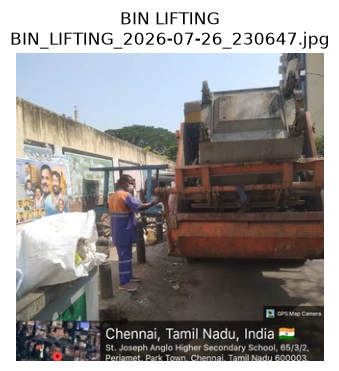

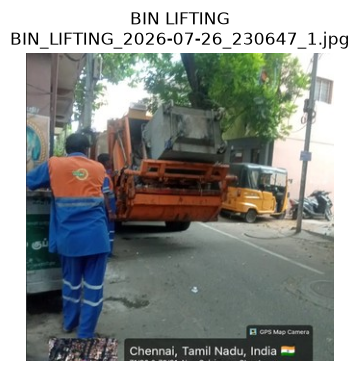

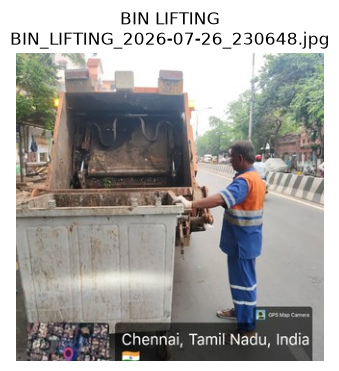

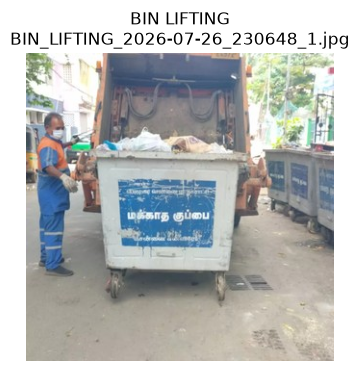

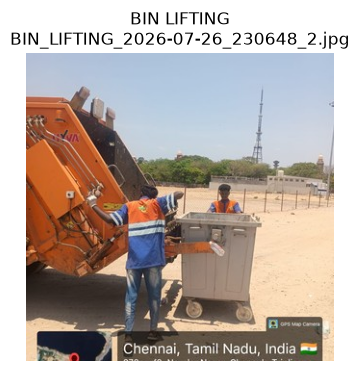

In [12]:
for result in roundtrip_results:
    fetched_image = Image.open(
        BytesIO(result["fetched_bytes"])
    ).convert("RGB")

    plt.figure(figsize=(5, 4))
    plt.imshow(fetched_image)
    plt.title(
        f"{result['class_name']}\n"
        f"{result['filename']}"
    )
    plt.axis("off")
    plt.show()

In [13]:
assert len(roundtrip_results) == 5

assert all(
    result["bytes_match"]
    for result in roundtrip_results
)

print("=" * 60)
print("SQLITE ROUND-TRIP TEST PASSED")
print("=" * 60)
print("Images inserted: 5")
print("Images fetched: 5")
print("Byte equality: PASSED")
print("PIL image opening: PASSED")

SQLITE ROUND-TRIP TEST PASSED
Images inserted: 5
Images fetched: 5
Byte equality: PASSED
PIL image opening: PASSED
